In [36]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("credit_risk_dataset.csv")
X = df.drop(columns=['loan_status'])
y = df["loan_status"]


grade_categories = sorted(list(set(df["loan_grade"])), reverse=True)


preprocessor = ColumnTransformer(
    transformers=[
        # Обычные текстовые категории -> в отдельные колонки
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['person_home_ownership', 'loan_intent']),
        
        # Порядковый текст -> в правильные числа
        ('ordinal', OrdinalEncoder(categories=[grade_categories]), ['loan_grade']),
        
        # Бинарный текст Y/N -> в 0 и 1
        ('binary', OneHotEncoder(drop='if_binary'), ['cb_person_default_on_file'])
    ],
    # Все остальные числовые колонки пропускаем без изменений
    remainder='passthrough' 
)

# 3. Собираем всё в единый конвейер (Pipeline)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
# 2. Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Accuracy: 90.58%

Classification Report обыч:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      5072
           1       0.96      0.60      0.74      1445

    accuracy                           0.91      6517
   macro avg       0.93      0.80      0.84      6517
weighted avg       0.91      0.91      0.90      6517

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5072
           1       0.74      0.74      0.74      1445

    accuracy                           0.88      6517
   macro avg       0.83      0.83      0.83      6517
weighted avg       0.88      0.88      0.88      6517



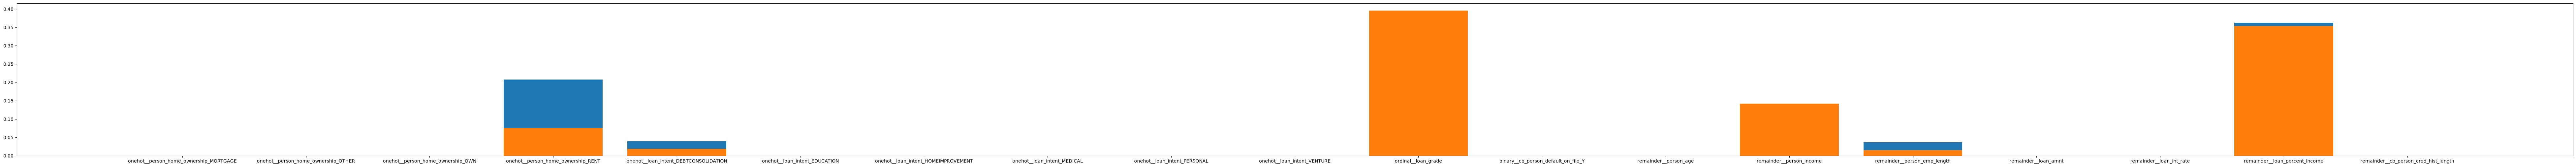

In [ ]:


# 4. Train the model
pipeline.fit(X_train, y_train)

# 5. Make predictions
y_pred = pipeline.predict(X_test)

# 6. Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report обыч:")
print(classification_report(y_test, y_pred))



In [ ]:
raw_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Очищаем имена от системных префиксов вроде 'onehot__' или 'remainder__', чтобы их было легко читать
clean_features = [
    name.replace('onehot__', '')
        .replace('remainder__', '')
        .replace('ordinal__', '')
        .replace('binary__', '') 
    for name in raw_names
]

# 2. Вытаскиваем важность признаков из обученного дерева решений
importances = pipeline.named_steps['classifier'].feature_importances_

# 3. Собираем всё в красивую DataFrame таблицу для удобной сортировки
df_importance = pd.DataFrame({
    'Признак': clean_features,
    'Вклад (Важность %)': importances * 100 # переводим в проценты
})

# Сортируем по убыванию вклада
df_importance = df_importance.sort_values(by='Вклад (Важность %)', ascending=False)

# 4. Выводим результат в консоль
print("=" * 60)
print(" ТОП ПРИЗНАКОВ, КОТОРЫЕ БОЛЬШЕ ВСЕГО ВЛИЯЮТ НА РЕШЕНИЕ ДЕРЕВА ")
print("=" * 60)
print(df_importance.to_string(index=False, float_format="%.2f%%"))
pipeline_balanced


# 4. Выводим результат в консоль
print("=" * 60)
print(" ТОП ПРИЗНАКОВ, КОТОРЫЕ БОЛЬШЕ ВСЕГО ВЛИЯЮТ НА РЕШЕНИЕ ДЕРЕВА BALANCED")
print("=" * 60)
print(df_importance.to_string(index=False, float_format="%.2f%%"))

 ТОП ПРИЗНАКОВ, КОТОРЫЕ БОЛЬШЕ ВСЕГО ВЛИЯЮТ НА РЕШЕНИЕ ДЕРЕВА 
                       Признак  Вклад (Важность %)
           loan_percent_income              36.26%
                    loan_grade              26.19%
    person_home_ownership_RENT              20.78%
                 person_income               9.05%
 loan_intent_DEBTCONSOLIDATION               4.00%
             person_emp_length               3.72%
person_home_ownership_MORTGAGE               0.00%
     person_home_ownership_OWN               0.00%
   person_home_ownership_OTHER               0.00%
   loan_intent_HOMEIMPROVEMENT               0.00%
         loan_intent_EDUCATION               0.00%
           loan_intent_VENTURE               0.00%
          loan_intent_PERSONAL               0.00%
           loan_intent_MEDICAL               0.00%
                    person_age               0.00%
   cb_person_default_on_file_Y               0.00%
                     loan_amnt               0.00%
                 lo

In [38]:
random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Включаем Случайный лес вместо DecisionTreeClassifier
    ('classifier', RandomForestClassifier(
        n_estimators=100,          # Количество деревьев в лесу
        max_depth=6,               # Максимальная глубина каждого дерева
        random_state=42,           # Для воспроизводимости результатов
        n_jobs=-1                  # Использовать все ядра процессора для ускорения
    ))
])

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

# 6. Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report обыч:")
print(classification_report(y_test, y_pred))




Accuracy: 92.51%

Classification Report обыч:
              precision    recall  f1-score   support

           0       0.92      1.00      0.95      5072
           1       0.98      0.68      0.80      1445

    accuracy                           0.93      6517
   macro avg       0.95      0.84      0.88      6517
weighted avg       0.93      0.93      0.92      6517



In [39]:
raw_names = random_forest.named_steps['preprocessor'].get_feature_names_out()

# Очищаем имена от системных префиксов вроде 'onehot__' или 'remainder__', чтобы их было легко читать
clean_features = [
    name.replace('onehot__', '')
        .replace('remainder__', '')
        .replace('ordinal__', '')
        .replace('binary__', '') 
    for name in raw_names
]

importances = random_forest.named_steps['classifier'].feature_importances_

# 3. Собираем всё в красивую DataFrame таблицу для удобной сортировки
df_importance = pd.DataFrame({
    'Признак': clean_features,
    'Вклад (Важность %)': importances * 100 # переводим в проценты
})

# Сортируем по убыванию вклада
df_importance = df_importance.sort_values(by='Вклад (Важность %)', ascending=False)

# 4. Выводим результат в консоль
print("=" * 60)
print(" ТОП ПРИЗНАКОВ, КОТОРЫЕ БОЛЬШЕ ВСЕГО ВЛИЯЮТ НА РЕШЕНИЕ ДЕРЕВА ")
print("=" * 60)
print(df_importance.to_string(index=False, float_format="%.2f%%"))



 ТОП ПРИЗНАКОВ, КОТОРЫЕ БОЛЬШЕ ВСЕГО ВЛИЯЮТ НА РЕШЕНИЕ ДЕРЕВА 
                       Признак  Вклад (Важность %)
           loan_percent_income              30.94%
                    loan_grade              17.44%
                 person_income              11.99%
                 loan_int_rate              11.09%
    person_home_ownership_RENT               8.63%
person_home_ownership_MORTGAGE               4.11%
                     loan_amnt               3.38%
     person_home_ownership_OWN               2.72%
             person_emp_length               2.22%
 loan_intent_DEBTCONSOLIDATION               1.84%
   cb_person_default_on_file_Y               1.82%
           loan_intent_MEDICAL               1.70%
   loan_intent_HOMEIMPROVEMENT               0.52%
         loan_intent_EDUCATION               0.51%
           loan_intent_VENTURE               0.47%
          loan_intent_PERSONAL               0.23%
                    person_age               0.22%
    cb_person_cred_